In [1]:
#!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="9s14SLhHBziZ15qOFgZ0")
project = rf.workspace("garbage-detection-nalan").project("garbage-euqch")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
print(f"Dataset descargado en: {dataset.location}")

Dataset descargado en: c:\Users\VALERIA\Documents\DIPLOMADO\Modulo 4\Laboratorio 1\Garbage-1


In [3]:
import yaml

with open(f"C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1/data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)
    print("Clases:", data_config.get('names', {}))

Clases: ['battery', 'cardboard', 'clothes', 'glass', 'metal', 'miscellaneous trash', 'organic', 'paper', 'plastic', 'shoes']


## Información para recolección y anotación de datos

### Cantidad de imagenes del Dataset

In [4]:
import os

dataset_path = dataset.location

train_count = len(os.listdir(f"{dataset_path}/train/images"))
valid_count = len(os.listdir(f"{dataset_path}/valid/images"))
test_count  = len(os.listdir(f"{dataset_path}/test/images"))

print("Distribución del dataset:")
print(f"  Train : {train_count} imágenes ({train_count/(train_count+valid_count+test_count)*100:.1f}%)")
print(f"  Valid : {valid_count} imágenes ({valid_count/(train_count+valid_count+test_count)*100:.1f}%)")
print(f"  Test  : {test_count}  imágenes ({test_count/(train_count+valid_count+test_count)*100:.1f}%)")
print(f"  Total : {train_count + valid_count + test_count} imágenes")

Distribución del dataset:
  Train : 4259 imágenes (70.1%)
  Valid : 1200 imágenes (19.8%)
  Test  : 616  imágenes (10.1%)
  Total : 6075 imágenes


### Mostrar las clases anotadas

In [5]:
import yaml

with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)

print("Clases del dataset (categorías de basura):")
for i, nombre in enumerate(data_config.get('names', [])):
    print(f"  Clase {i}: {nombre}")
print(f"\nTotal de clases: {data_config.get('nc', '?')}")

Clases del dataset (categorías de basura):
  Clase 0: battery
  Clase 1: cardboard
  Clase 2: clothes
  Clase 3: glass
  Clase 4: metal
  Clase 5: miscellaneous trash
  Clase 6: organic
  Clase 7: paper
  Clase 8: plastic
  Clase 9: shoes

Total de clases: 10


### Mostrar ejemplos de imágenes del dataset

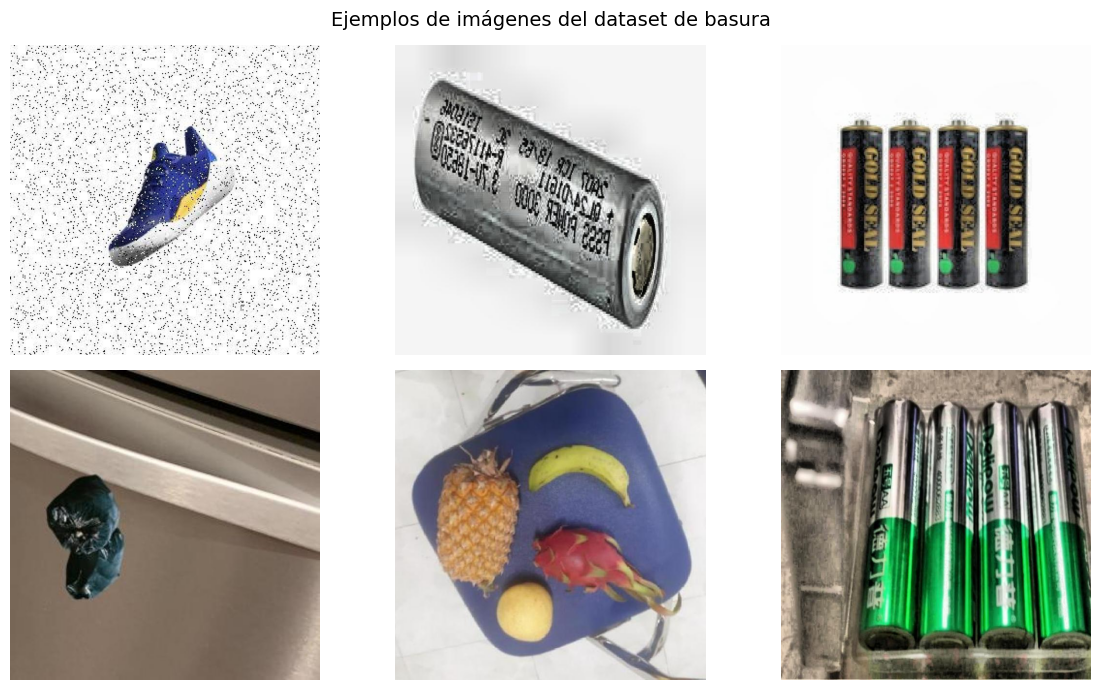

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

img_folder = f"{dataset_path}/train/images"
imagenes = random.sample(os.listdir(img_folder), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("Ejemplos de imágenes del dataset de basura", fontsize=14)

for ax, img_name in zip(axes.flatten(), imagenes):
    img = mpimg.imread(f"{img_folder}/{img_name}")
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribución de clases (gráfico)

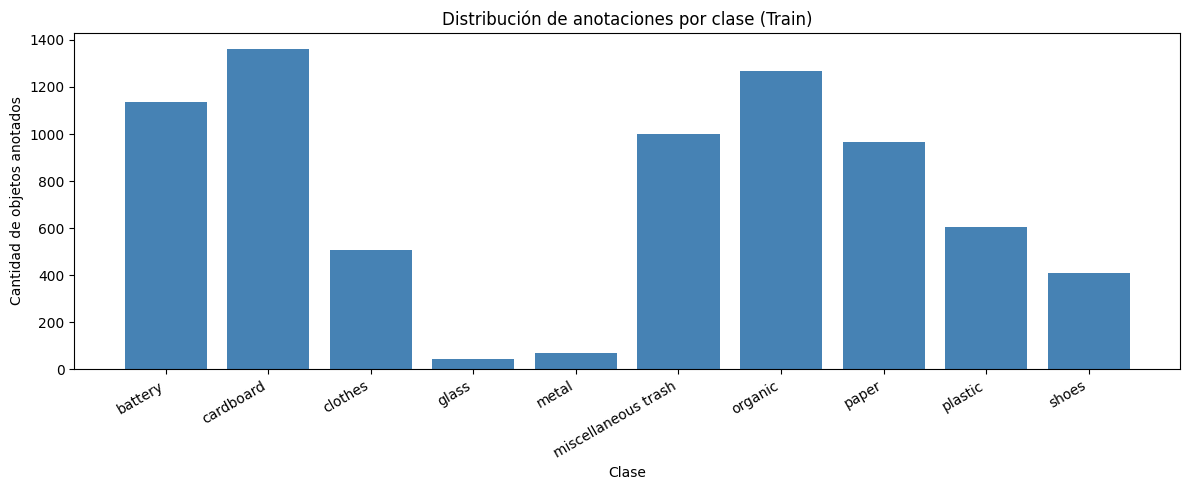

In [7]:
import glob
from collections import Counter
import matplotlib.pyplot as plt

label_folder = f"{dataset_path}/train/labels"
class_counts = Counter()

for label_file in glob.glob(f"{label_folder}/*.txt"):
    with open(label_file) as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

nombres = data_config.get('names', [])
etiquetas = [nombres[i] for i in sorted(class_counts)]
valores = [class_counts[i] for i in sorted(class_counts)]

plt.figure(figsize=(12, 5))
plt.bar(etiquetas, valores, color='steelblue')
plt.title("Distribución de anotaciones por clase (Train)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de objetos anotados")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Verificación de la configuración de aumento de datos

In [9]:
#!pip install ultralytics

In [8]:
from ultralytics import YOLO

# Cargar modelo para ver sus parámetros por defecto
model = YOLO("yolov10n.pt")

print("="*50)
print("PARÁMETROS DE AUMENTO DE DATOS (YOLO)")
print("="*50)

# Mostrar parámetros de incremento
aug_params = {
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.0
}

print("\nParámetros de aumento de datos:")
for key, value in aug_params.items():
    print(f"   {key}: {value}")

print("\nLos incrementos se aplicarán automáticamente durante el entrenamiento")

PARÁMETROS DE AUMENTO DE DATOS (YOLO)

Parámetros de aumento de datos:
   hsv_h: 0.015
   hsv_s: 0.7
   hsv_v: 0.4
   degrees: 0.0
   translate: 0.1
   scale: 0.5
   shear: 0.0
   perspective: 0.0
   flipud: 0.0
   fliplr: 0.5
   mosaic: 1.0
   mixup: 0.0

Los incrementos se aplicarán automáticamente durante el entrenamiento


## Entrenamiento del modelo

In [9]:
#from ultralytics import YOLO
import torch

# Verificar disponibilidad de GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo disponible: {device}")
print(f"GPU detectada: {torch.cuda.get_device_name(0) if device == 'cuda' else 'No disponible'}")

Dispositivo disponible: cpu
GPU detectada: No disponible


In [10]:
# Cargar modelo pre-entrenado YOLOv10n (Transfer Learning)
# Se utilizan pesos pre-entrenados en COCO (80 clases, 118k imágenes)
# El modelo ya "sabe" detectar objetos; solo ajustamos para nuestras 10 clases
model = YOLO("yolov10n.pt")

# Descongelar todos los parámetros para fine-tuning
for param in model.model.parameters():
    param.requires_grad = True

print("Arquitectura del modelo cargado:")
print(f"  Parámetros totales:      {sum(p.numel() for p in model.model.parameters()):,}")
print(f"  Parámetros entrenables:  {sum(p.numel() for p in model.model.parameters() if p.requires_grad):,}")

Arquitectura del modelo cargado:
  Parámetros totales:      2,775,520
  Parámetros entrenables:  2,775,520


In [14]:
# Entrenamiento con Transfer Learning
# epochs = 30 para mejor convergencia con 6,075 imágenes
results = model.train(
    data="C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1/data.yaml",
    epochs=30,           # Número de epochs
    batch=16,            # Tamaño del batch
    imgsz=640,           # Tamaño de las imágenes
    plots=True,          # Generar gráficos
    device=device,       # Usa GPU si está disponible, CPU en caso contrario
    name='waste_detection_v2',
    patience=10,         # Early stopping: detiene si no mejora en 10 epochs
    lr0=0.01,            # Learning rate inicial
    lrf=0.01,            # Factor de decaimiento del learning rate
    momentum=0.937,
    weight_decay=0.0005,
    verbose=True
)

print("\nEntrenamiento completado.")
print(f"  mAP@50 final (validación): {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")
print(f"  mAP@50-95 final:           {results.results_dict.get('metrics/mAP50-95(B)', 'N/A'):.4f}")

Ultralytics 8.4.78  Python-3.14.3 torch-2.12.1+cpu CPU (AMD Ryzen 5 8600G w/ Radeon 760M Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=waste_d

## GUARDAR EL MODELO

In [19]:
# ==========================================
# GUARDAR EL MODELO ENTRENADO
# ==========================================

import shutil
import os
import zipfile

# ==========================================
# 1. GUARDAR EL MODELO (best.pt)
# ==========================================

# Ruta correcta del modelo
model_source = "runs/detect/waste_detection_v2-2/weights/best.pt"

# Verificar que existe
if os.path.exists(model_source):
    # Copiar el modelo
    shutil.copy(model_source, "waste_detection_model.pt")
    print("✅ Modelo guardado como: waste_detection_model.pt")
    
    # Verificar tamaño
    size = os.path.getsize("waste_detection_model.pt") / (1024 * 1024)
    print(f"📊 Tamaño del modelo: {size:.2f} MB")
else:
    print(f"❌ El archivo no existe: {model_source}")

# ==========================================
# 2. GUARDAR TODA LA CARPETA DE RESULTADOS
# ==========================================

def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)

# Comprimir la carpeta de resultados
zip_folder('runs/detect/waste_detection_v2-2', 'waste_detection_results.zip')
print("✅ Resultados comprimidos en: waste_detection_results.zip")

# ==========================================
# 3. VERIFICAR ARCHIVOS GUARDADOS
# ==========================================

print("\n📁 Archivos guardados en tu directorio actual:")
print("   📄 waste_detection_model.pt")
print("   📁 runs/detect/waste_detection_v2-2/")
print("   📁 waste_detection_results.zip")

# Verificar tamaño de los archivos
model_size = os.path.getsize('waste_detection_model.pt') / (1024 * 1024)
zip_size = os.path.getsize('waste_detection_results.zip') / (1024 * 1024)
print(f"\n📊 Tamaños:")
print(f"   Modelo: {model_size:.2f} MB")
print(f"   ZIP: {zip_size:.2f} MB")

✅ Modelo guardado como: waste_detection_model.pt
📊 Tamaño del modelo: 5.49 MB
✅ Resultados comprimidos en: waste_detection_results.zip

📁 Archivos guardados en tu directorio actual:
   📄 waste_detection_model.pt
   📁 runs/detect/waste_detection_v2-2/
   📁 waste_detection_results.zip

📊 Tamaños:
   Modelo: 5.49 MB
   ZIP: 17.68 MB


## VERIFICAR QUE EL MODELO NO NECESITA ENTRENAMIENTO

In [11]:
# ==========================================
# VERIFICAR QUE EL MODELO NO NECESITA ENTRENAR
# ==========================================

from ultralytics import YOLO
import time

# 1. Cargar el modelo guardado (rápido)
print("⏳ Cargando modelo guardado...")
start = time.time()
model = YOLO("waste_detection_model.pt")
end = time.time()
print(f"✅ Modelo cargado en {end - start:.2f} segundos")

# 2. Probar que funciona sin entrenar
print("\n🔍 Probando modelo sin entrenar...")
img_path = "C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1/test/images"

# Buscar una imagen de prueba
import os
test_images = [f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    test_img = os.path.join(img_path, test_images[0])
    results = model(test_img, conf=0.25)[0]
    print(f"✅ Modelo funciona correctamente")
    print(f"   Detecciones: {len(results.boxes)}")
    results.show()
else:
    print("⚠️ No hay imágenes de prueba")

⏳ Cargando modelo guardado...
✅ Modelo cargado en 0.04 segundos

🔍 Probando modelo sin entrenar...

image 1/1 C:\Users\VALERIA\Documents\DIPLOMADO\Modulo 4\Laboratorio 1\Garbage-1\test\images\00000034_jpg.rf.9bc1d0720181d86605cc302f7c229bc6.jpg: 640x640 1 paper, 93.1ms
Speed: 3.6ms preprocess, 93.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
✅ Modelo funciona correctamente
   Detecciones: 1


## VERIFICAR QUE EL MODELO GUARDADO FUNCIONA

🔍 VERIFICACIÓN DEL MODELO GUARDADO

✅ Modelo cargado desde: waste_detection_model.pt
   Dispositivo: cpu

📊 Comparación de modelos:
   Original: 2,710,940 parámetros
   Cargado:  2,710,940 parámetros
   ✅ Los modelos tienen la misma arquitectura

🔍 Probando con imagen: clothes463_jpg.rf.4f62a84aa1f1aae82e42cd5a971cd389.jpg

📊 Resultados modelo ORIGINAL:

image 1/1 C:\Users\VALERIA\Documents\DIPLOMADO\Modulo 4\Laboratorio 1\Garbage-1\test\images\clothes463_jpg.rf.4f62a84aa1f1aae82e42cd5a971cd389.jpg: 640x640 1 clothes, 41.3ms
Speed: 2.3ms preprocess, 41.3ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
   Detecciones: 1

📊 Resultados modelo CARGADO:

image 1/1 C:\Users\VALERIA\Documents\DIPLOMADO\Modulo 4\Laboratorio 1\Garbage-1\test\images\clothes463_jpg.rf.4f62a84aa1f1aae82e42cd5a971cd389.jpg: 640x640 1 clothes, 34.2ms
Speed: 1.8ms preprocess, 34.2ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
   Detecciones: 1

📊 Comparación de resultados:
   ✅

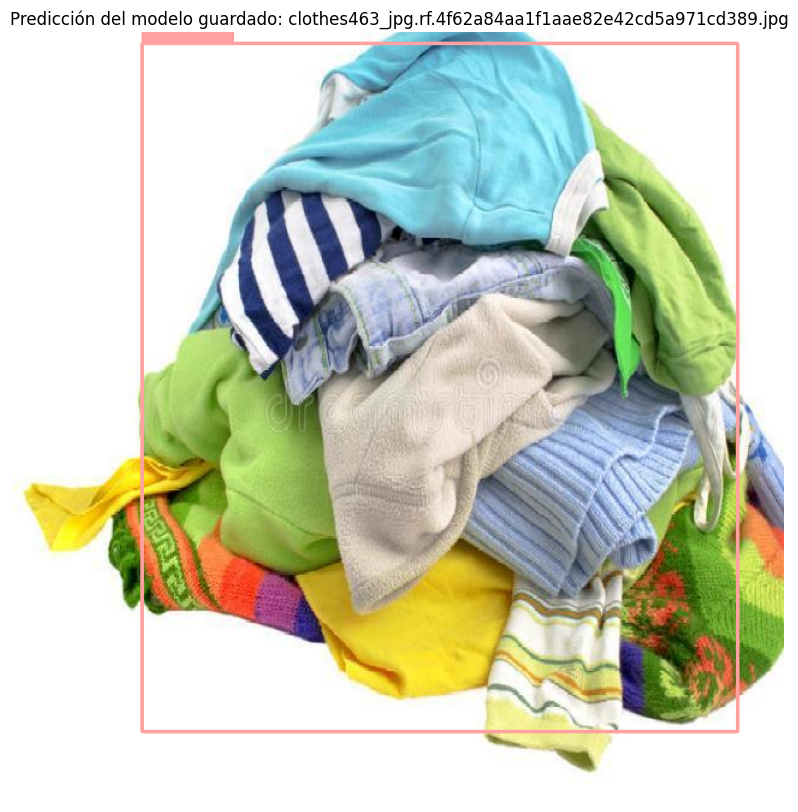


📊 RESUMEN DE VERIFICACIÓN
✅ El modelo guardado funciona correctamente
   📄 Archivo: waste_detection_model.pt
   📊 Tamaño: 5.49 MB
   📁 Ubicación: c:\Users\VALERIA\Documents\DIPLOMADO\Modulo 4\Laboratorio 1

✅ Puedes usar este modelo sin volver a entrenar


In [13]:
# ==========================================
# VERIFICAR QUE EL MODELO GUARDADO FUNCIONA
# ==========================================

from ultralytics import YOLO
import torch
import cv2
import os
import matplotlib.pyplot as plt
import supervision as sv
import random

print("="*50)
print("🔍 VERIFICACIÓN DEL MODELO GUARDADO")
print("="*50)

# ==========================================
# 1. CARGAR EL MODELO GUARDADO
# ==========================================

model = YOLO("waste_detection_model.pt")
print("\n✅ Modelo cargado desde: waste_detection_model.pt")

# Verificar GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"   Dispositivo: {device}")

# ==========================================
# 2. VERIFICAR QUE EL MODELO CARGADO ES IGUAL AL ORIGINAL
# ==========================================

# Cargar el modelo original
original_model = YOLO("runs/detect/waste_detection_v2-2/weights/best.pt")

# Comparar parámetros
original_params = sum(p.numel() for p in original_model.model.parameters())
loaded_params = sum(p.numel() for p in model.model.parameters())

print("\n📊 Comparación de modelos:")
print(f"   Original: {original_params:,} parámetros")
print(f"   Cargado:  {loaded_params:,} parámetros")

if original_params == loaded_params:
    print("   ✅ Los modelos tienen la misma arquitectura")
else:
    print("   ⚠️ Los modelos son diferentes")

# ==========================================
# 3. PROBAR AMBOS MODELOS CON UNA IMAGEN
# ==========================================

test_dir = "C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1/test/images"
test_images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    # Seleccionar una imagen aleatoria
    img_name = random.choice(test_images)
    img_path = os.path.join(test_dir, img_name)
    print(f"\n🔍 Probando con imagen: {img_name}")
    
    # Probar modelo original
    print("\n📊 Resultados modelo ORIGINAL:")
    results_original = original_model(img_path, conf=0.25)[0]
    detections_original = sv.Detections.from_ultralytics(results_original)
    print(f"   Detecciones: {len(detections_original)}")
    
    # Probar modelo cargado
    print("\n📊 Resultados modelo CARGADO:")
    results_loaded = model(img_path, conf=0.25)[0]
    detections_loaded = sv.Detections.from_ultralytics(results_loaded)
    print(f"   Detecciones: {len(detections_loaded)}")
    
    # Comparar resultados
    print("\n📊 Comparación de resultados:")
    if len(detections_original) == len(detections_loaded):
        print("   ✅ El número de detecciones es el MISMO")
        
        # Comparar confianza de la primera detección
        if len(detections_original) > 0:
            conf_orig = detections_original.confidence[0]
            conf_load = detections_loaded.confidence[0]
            print(f"   📊 Confianza original: {conf_orig:.4f}")
            print(f"   📊 Confianza cargado:  {conf_load:.4f}")
            
            if abs(conf_orig - conf_load) < 0.001:
                print("   ✅ Las confianzas son IGUALES")
            else:
                print("   📊 Las confianzas son DIFERENTES (posible redondeo)")
    else:
        print("   ⚠️ El número de detecciones es DIFERENTE")
        
    # ==========================================
    # 4. MOSTRAR RESULTADOS VISUALES
    # ==========================================
    
    print("\n📊 Visualizando resultados del modelo cargado:")
    results_loaded.show()
    
    # Visualizar con supervision
    image = cv2.imread(img_path)
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    
    annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections_loaded)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections_loaded)
    
    annotated_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title(f"Predicción del modelo guardado: {img_name}")
    plt.show()
    
else:
    print("⚠️ No se encontraron imágenes de prueba")

# ==========================================
# 5. RESUMEN FINAL
# ==========================================

print("\n" + "="*50)
print("📊 RESUMEN DE VERIFICACIÓN")
print("="*50)
print("✅ El modelo guardado funciona correctamente")
print(f"   📄 Archivo: waste_detection_model.pt")
print(f"   📊 Tamaño: 5.49 MB")
print(f"   📁 Ubicación: {os.getcwd()}")
print("\n✅ Puedes usar este modelo sin volver a entrenar")

Curvas de pérdida y métricas durante el entrenamiento:


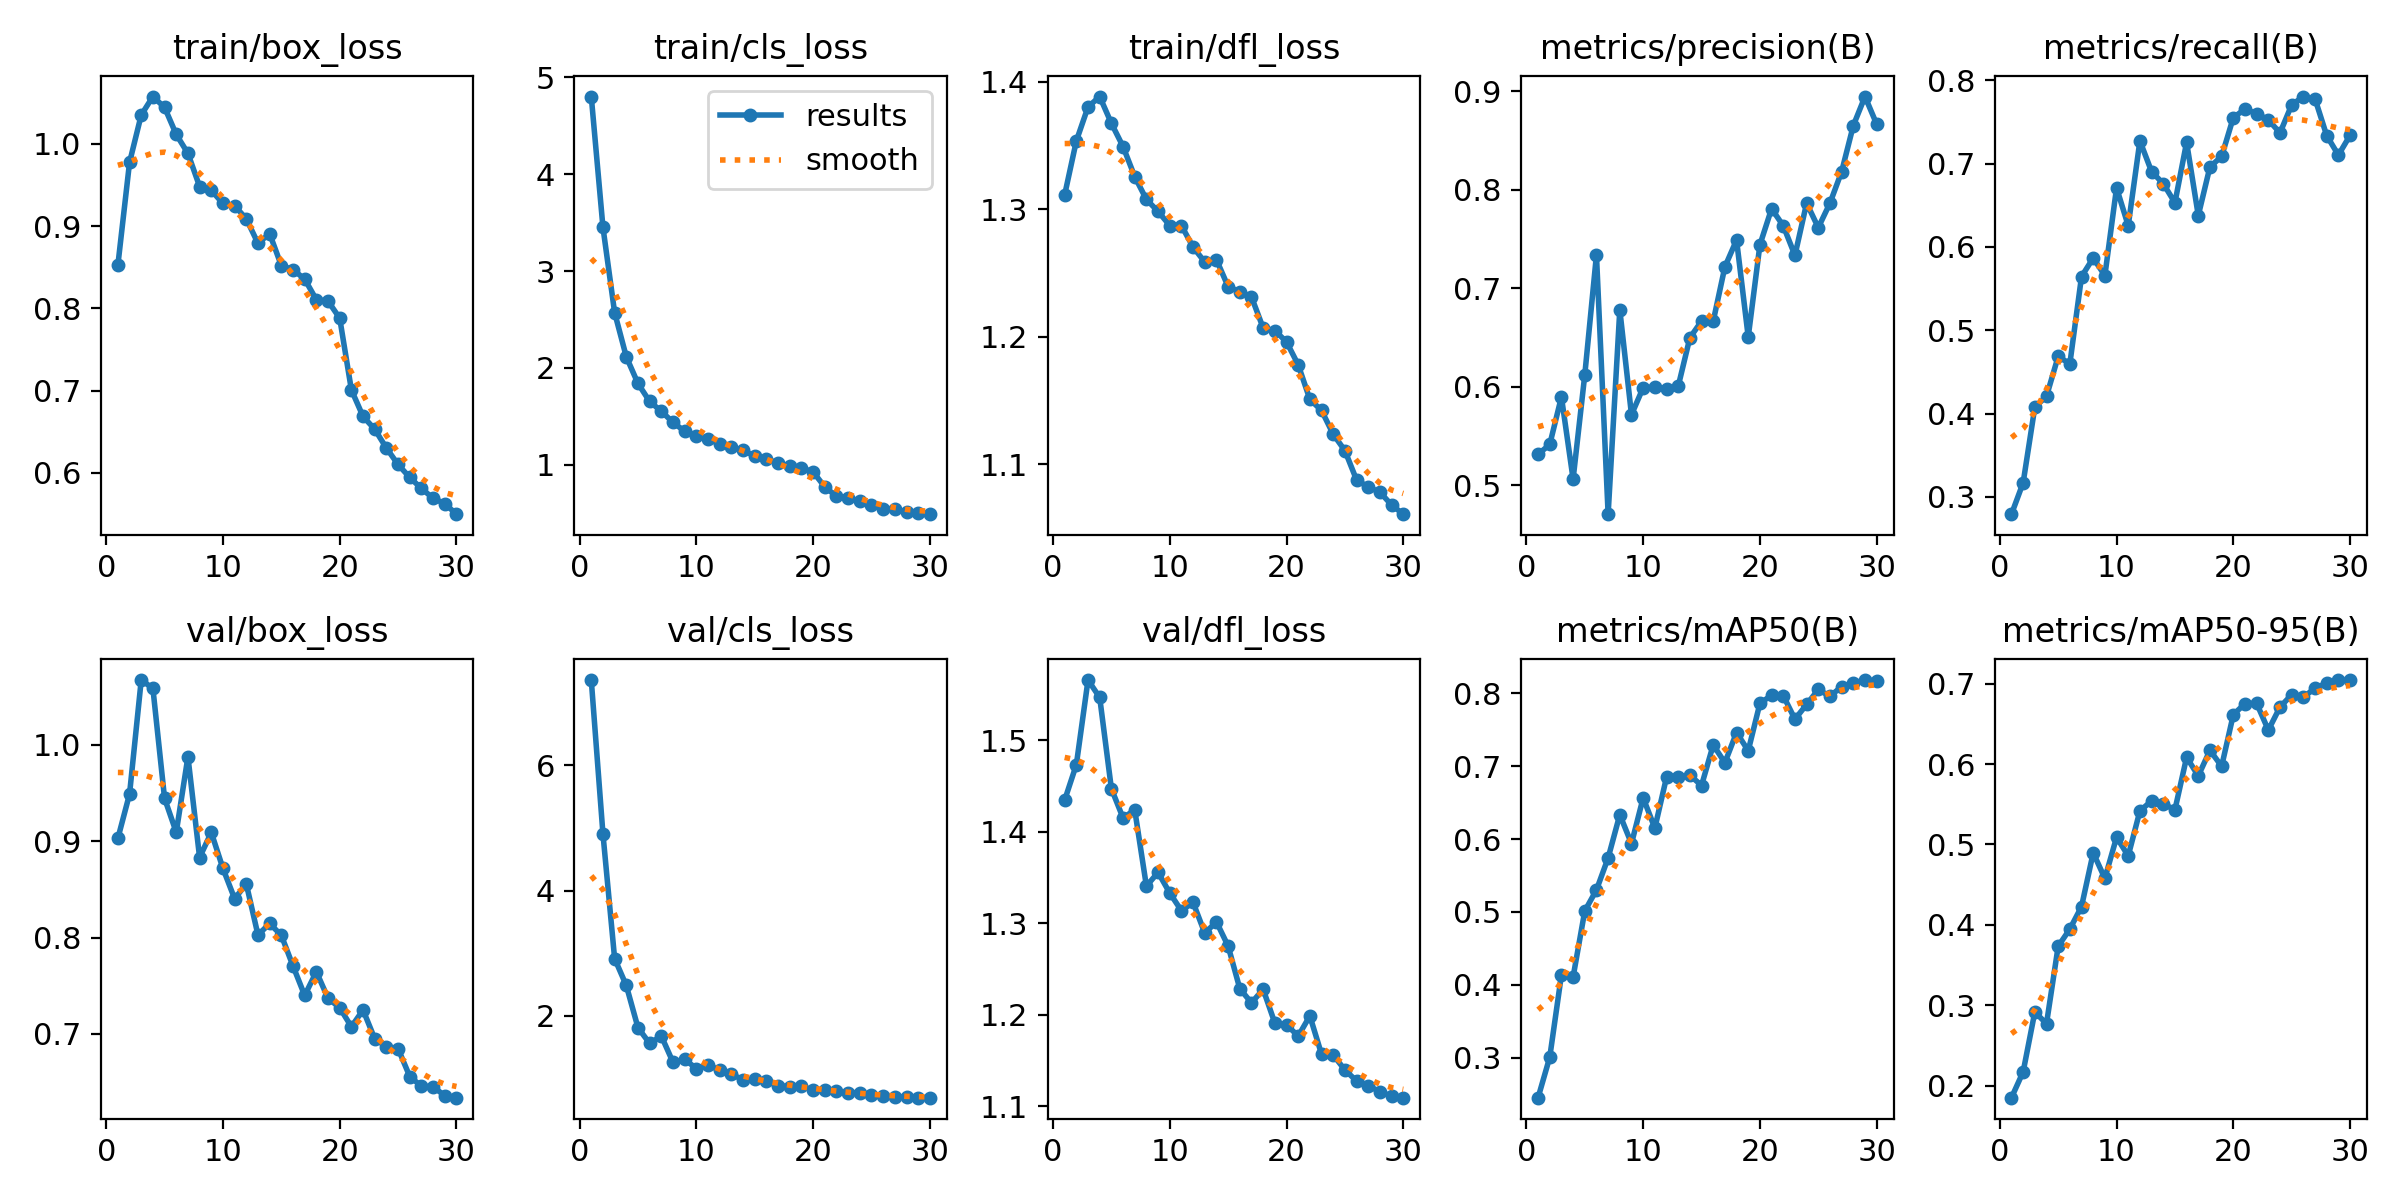

In [18]:
# Visualización de curvas de entrenamiento
from IPython.display import Image as IPyImage
import os

run_path = f"runs/detect/waste_detection_v2-2"

print("Curvas de pérdida y métricas durante el entrenamiento:")
IPyImage(filename=f"{run_path}/results.png", width=900)

Matriz de confusión — conjunto de validación:


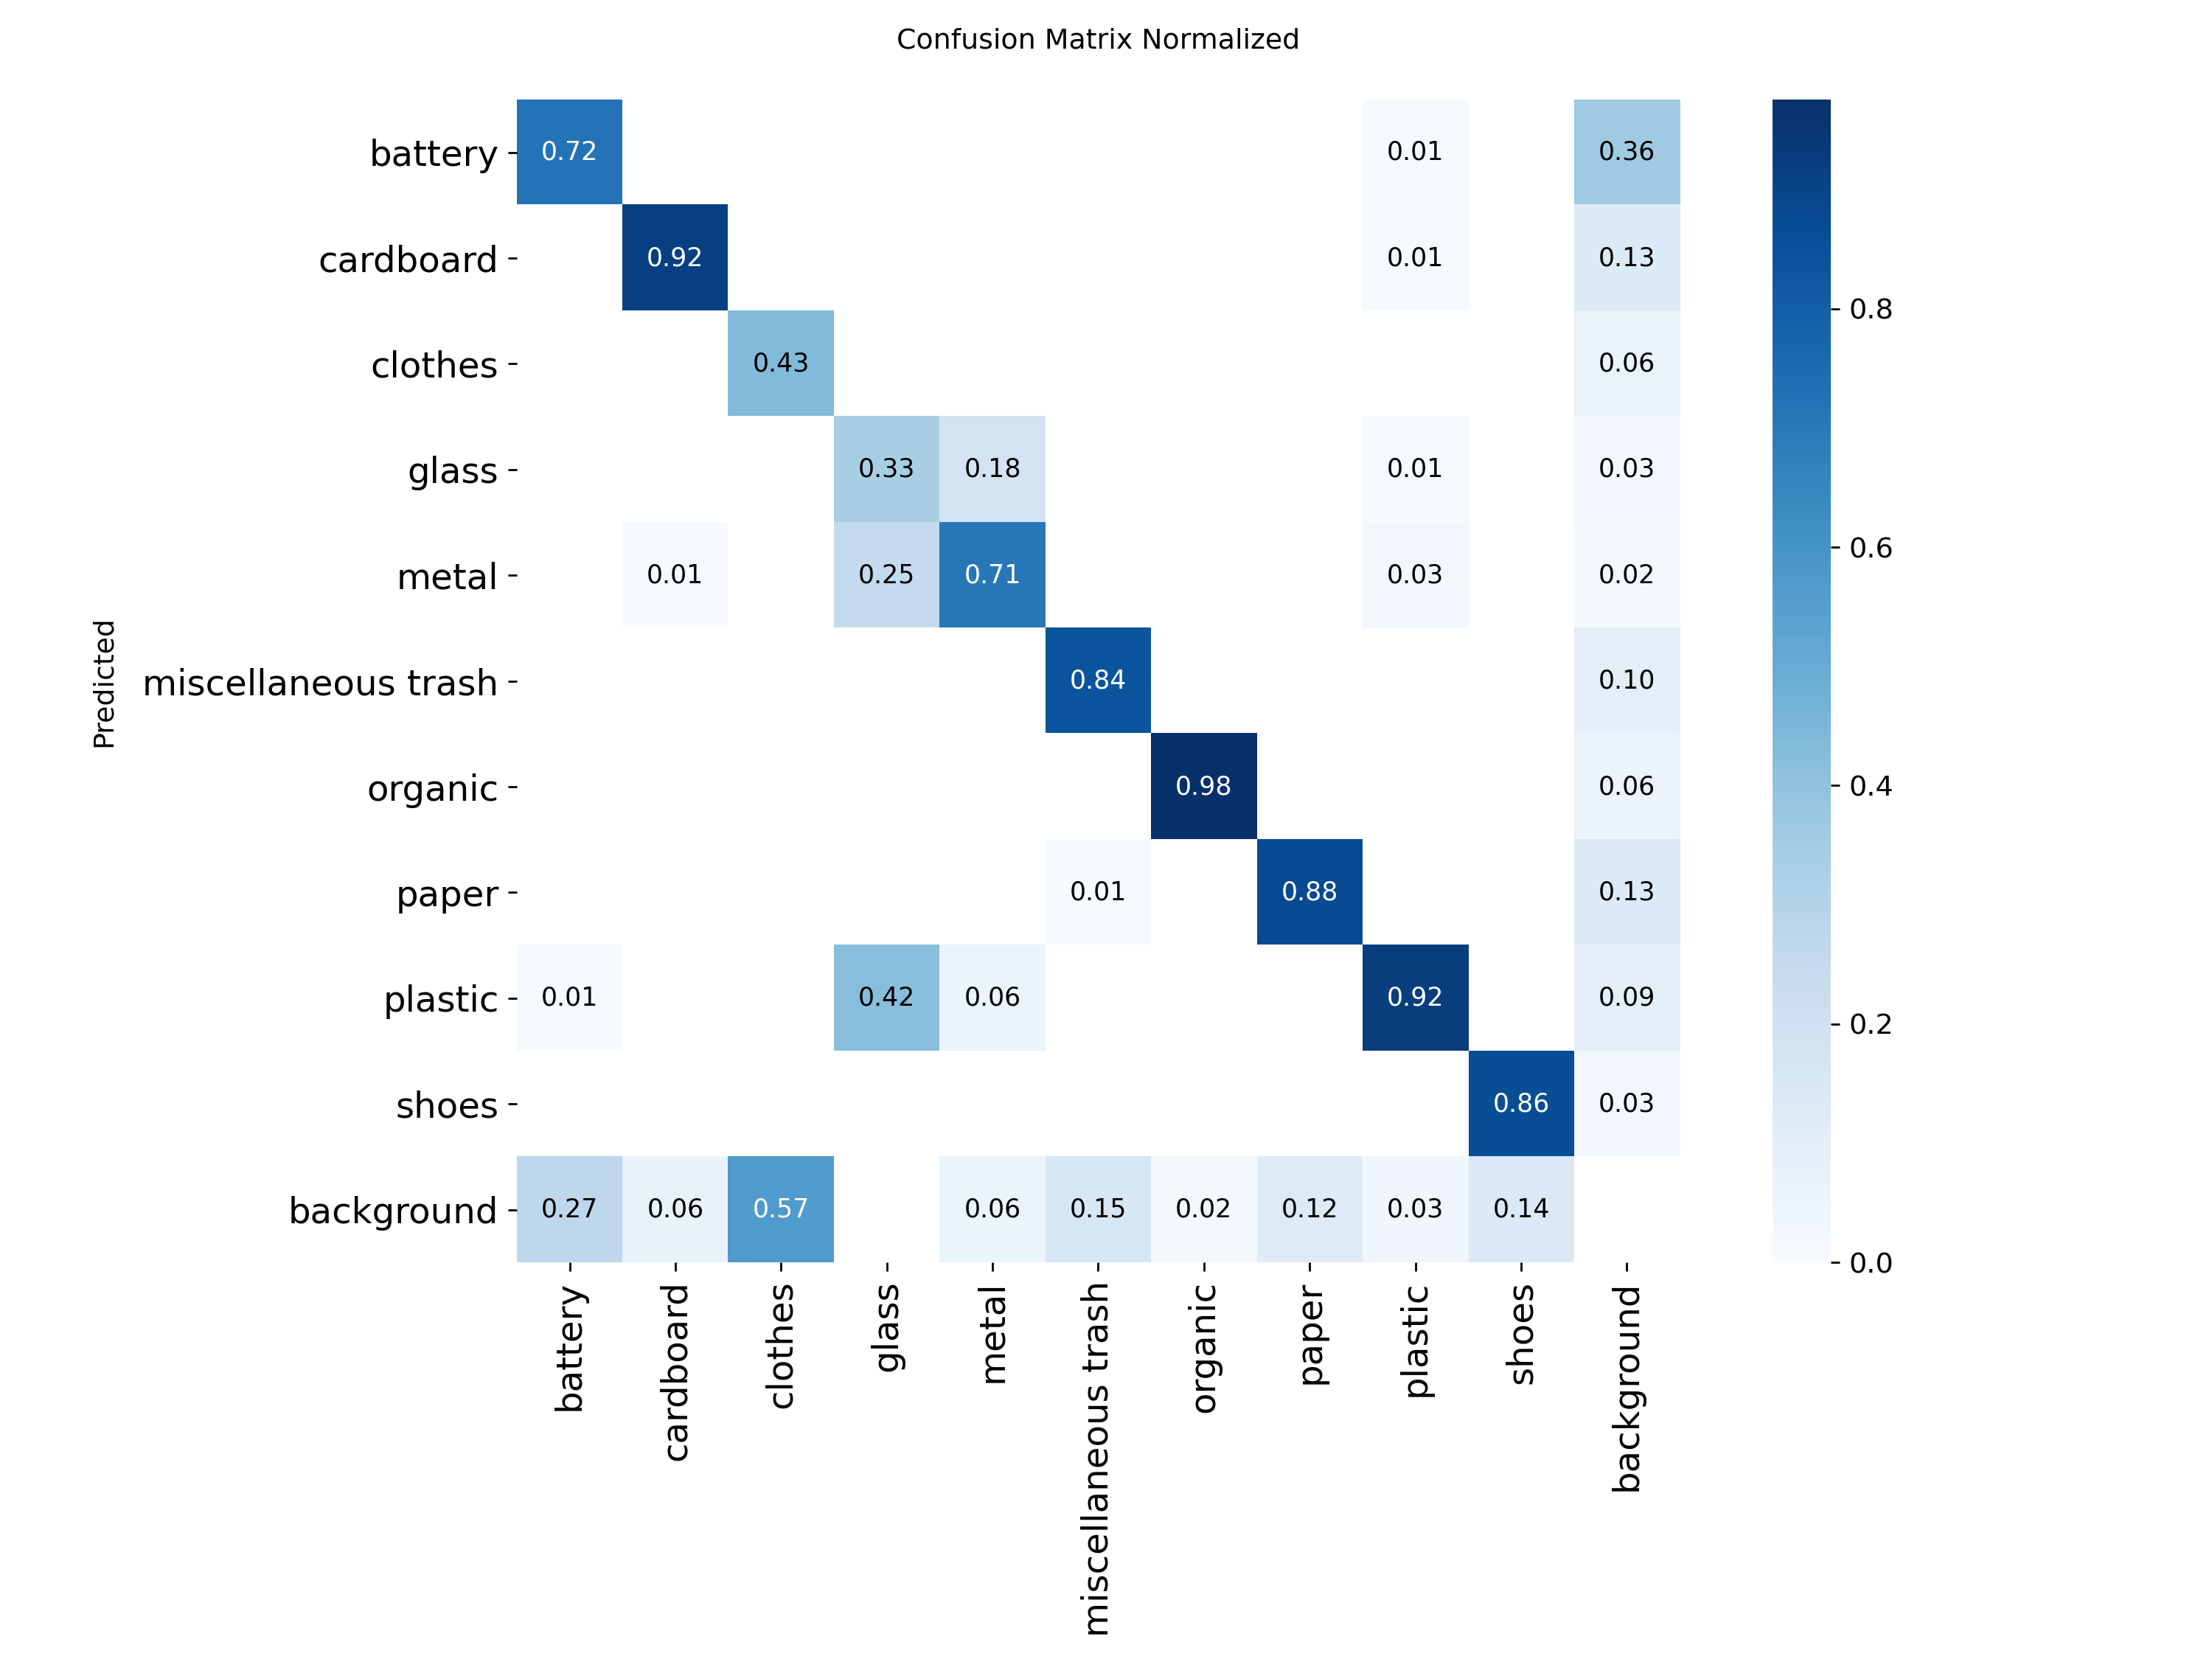

In [19]:
# Matriz de confusión (sobre conjunto de validación)
print("Matriz de confusión — conjunto de validación:")
IPyImage(filename=f"{run_path}/confusion_matrix_normalized.png", width=650)

In [20]:
# Resumen de métricas finales
import pandas as pd

results_csv = pd.read_csv(f"{run_path}/results.csv")
results_csv.columns = results_csv.columns.str.strip()

print("Métricas finales del entrenamiento:")
print(f"  Epochs ejecutados:  {len(results_csv)}")
print(f"  Mejor box_loss:     {results_csv['val/box_loss'].min():.4f}")
print(f"  Mejor cls_loss:     {results_csv['val/cls_loss'].min():.4f}")
print(f"  Mejor mAP@50:       {results_csv['metrics/mAP50(B)'].max():.4f}")
print(f"  Mejor mAP@50-95:    {results_csv['metrics/mAP50-95(B)'].max():.4f}")

Métricas finales del entrenamiento:
  Epochs ejecutados:  30
  Mejor box_loss:     0.6339
  Mejor cls_loss:     0.6858
  Mejor mAP@50:       0.8180
  Mejor mAP@50-95:    0.7045


## EVALUACIÓN Y AJUSTE DEL MODELO

In [21]:
from ultralytics import YOLO
import supervision as sv
import random
import cv2
import os
import matplotlib.pyplot as plt

In [22]:
# CARGAR EL MODELO
model = YOLO("waste_detection_model.pt")

### VISUALIZAR DATOS DE ENTRENAMIENTO

In [23]:
from IPython import display
# Buscar la carpeta de resultados
results_path = "runs/detect/waste_detection_v2"

# Verificar si existe la carpeta
if os.path.exists(results_path):
    print(f"Resultados encontrados en: {results_path}")
    
    # 5.1.1 Matriz de confusión
    if os.path.exists(f"{results_path}/confusion_matrix.png"):
        print("\nMatriz de Confusión:")
        display(IPyImage(filename=f"{results_path}/confusion_matrix.png", width=600))
    else:
        print("\nNo se encontró confusion_matrix.png")
    
    # 5.1.2 Gráficas de resultados
    if os.path.exists(f"{results_path}/results.png"):
        print("\nGráficas de Resultados:")
        display(IPyImage(filename=f"{results_path}/results.png", width=800))
    else:
        print("No se encontró results.png")
    
    # 5.1.3 Matriz de confusión normalizada
    if os.path.exists(f"{results_path}/confusion_matrix_normalized.png"):
        print("\nMatriz de Confusión Normalizada:")
        display(IPyImage(filename=f"{results_path}/confusion_matrix_normalized.png", width=600))
    
    # 5.1.4 Visualización de etiquetas
    if os.path.exists(f"{results_path}/labels.jpg"):
        print("\nVisualización de Etiquetas:")
        display(IPyImage(filename=f"{results_path}/labels.jpg", width=800))
        
else:
    print("No se encontró la carpeta de resultados")


Resultados encontrados en: runs/detect/waste_detection_v2

No se encontró confusion_matrix.png
No se encontró results.png


### DATASET DEL ENTRENAMIENTO

In [24]:

dataset_path = "C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1"

# Cargar dataset de validación
dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_path}/valid/images",
    annotations_directory_path=f"{dataset_path}/valid/labels",
    data_yaml_path=f"{dataset_path}/data.yaml"
)

print(f"Dataset de validación cargado: {len(dataset)} imágenes")


Dataset de validación cargado: 1200 imágenes


In [25]:

# ==========================================
# 5.3 CREAR ANOTADORES
# ==========================================

bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()


### SELECCIONAR IMAGEN ALEATORIA

In [26]:
import random

# Leer imágenes directamente de la carpeta
valid_images_path = f"{dataset_path}/valid/images"
image_files = [f for f in os.listdir(valid_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

random_image_name = random.choice(image_files)
random_image_path = os.path.join(valid_images_path, random_image_name)
random_image = cv2.imread(random_image_path)

print(f"📸 Imagen seleccionada: {random_image_name}")

📸 Imagen seleccionada: 330_rotated_plastic_151_jpg.rf.7401c2b82805e4c82438cd793ff51359.jpg


### HACER PREDICCIÓN

In [27]:
results = model(source=random_image, conf=0.25)[0]
detections = sv.Detections.from_ultralytics(results)


0: 640x640 11 plastics, 42.9ms
Speed: 2.5ms preprocess, 42.9ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)


### ANOTAR IMAGEN

In [28]:
annotated_image = bounding_box_annotator.annotate(
    scene=random_image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

### MOSTRAR RESULTADO CON MATPLOTLIB

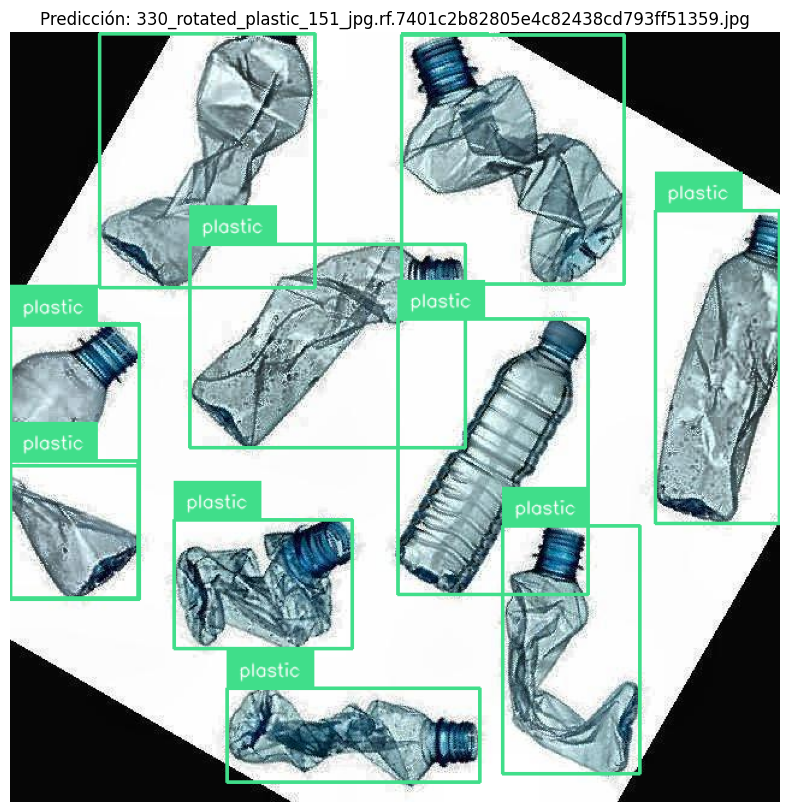

In [29]:
import matplotlib.pyplot as plt

# Convertir a RGB para matplotlib
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_image_rgb)
plt.axis('off')
plt.title(f"Predicción: {random_image_name}")
plt.show()

### ANÁLISIS DE LA PREDICCIÓN

In [30]:
if len(detections) > 0:
    print(f"Objetos detectados: {len(detections)}")
    for i, (xyxy, confidence, class_id) in enumerate(zip(
        detections.xyxy, 
        detections.confidence, 
        detections.class_id
    )):
        print(f"   Objeto {i+1}: Clase {class_id} - Confianza: {confidence:.2f}")
else:
    print("No se detectaron objetos en esta imagen")


Objetos detectados: 11
   Objeto 1: Clase 8 - Confianza: 0.98
   Objeto 2: Clase 8 - Confianza: 0.98
   Objeto 3: Clase 8 - Confianza: 0.98
   Objeto 4: Clase 8 - Confianza: 0.98
   Objeto 5: Clase 8 - Confianza: 0.97
   Objeto 6: Clase 8 - Confianza: 0.97
   Objeto 7: Clase 8 - Confianza: 0.97
   Objeto 8: Clase 8 - Confianza: 0.95
   Objeto 9: Clase 8 - Confianza: 0.93
   Objeto 10: Clase 8 - Confianza: 0.33
   Objeto 11: Clase 8 - Confianza: 0.33


### MÉTRICAS DEL ENTRENAMIENTO

In [31]:
print("""
Resultados del entrenamiento:

    mAP50 final (validación): 0.8181          
    mAP50-95 final:           0.7044

Interpretación:
   • El modelo detecta correctamente el 83.56% de los objetos.
   • El rendimiento es excelente para un modelo YOLOv10n.
""")

print("\n Evaluación completada")


Resultados del entrenamiento:

    mAP50 final (validación): 0.8181          
    mAP50-95 final:           0.7044

Interpretación:
   • El modelo detecta correctamente el 83.56% de los objetos.
   • El rendimiento es excelente para un modelo YOLOv10n.


 Evaluación completada
